Using Device: cuda

Loading Dataset...

Processing: skin_cancer
Subclass: Skin cancer ISIC The International Skin Imaging Collaboration
Subclass: skin cancer isic the international skin imaging collaboration
Processing: brain_tumor
Subclass: no_tumor
Subclass: pituitary_tumor
Subclass: meningioma_tumor
Subclass: glioma_tumor
Processing: diabetic_retinopathy
Subclass: Severe DR
Subclass: Healthy
Subclass: Moderate DR
Subclass: Mild DR
Subclass: Proliferate DR

Total Classes: 11
Class Names:

0 : Skin cancer ISIC The International Skin Imaging Collaboration
1 : skin cancer isic the international skin imaging collaboration
2 : no_tumor
3 : pituitary_tumor
4 : meningioma_tumor
5 : glioma_tumor
6 : Severe DR
7 : Healthy
8 : Moderate DR
9 : Mild DR
10 : Proliferate DR


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]


Starting Training...


Epoch [1/10]
Train Loss: 1.0589
Train Accuracy: 60.97%
Validation Loss: 0.6280
Validation Accuracy: 77.94%

Epoch [2/10]
Train Loss: 0.6400
Train Accuracy: 76.67%
Validation Loss: 0.5180
Validation Accuracy: 81.76%

Epoch [3/10]
Train Loss: 0.5354
Train Accuracy: 80.36%
Validation Loss: 0.5346
Validation Accuracy: 81.67%

Epoch [4/10]
Train Loss: 0.4798
Train Accuracy: 82.76%
Validation Loss: 0.5005
Validation Accuracy: 82.30%

Epoch [5/10]
Train Loss: 0.4296
Train Accuracy: 83.92%
Validation Loss: 0.4764
Validation Accuracy: 84.07%

Epoch [6/10]
Train Loss: 0.4065
Train Accuracy: 84.70%
Validation Loss: 0.4523
Validation Accuracy: 84.43%

Epoch [7/10]
Train Loss: 0.3879
Train Accuracy: 85.54%
Validation Loss: 0.4118
Validation Accuracy: 84.61%

Epoch [8/10]
Train Loss: 0.3632
Train Accuracy: 86.12%
Validation Loss: 0.4183
Validation Accuracy: 84.79%

Epoch [9/10]
Train Loss: 0.3284
Train Accuracy: 87.43%
Validation Loss: 0.3938
Validation Accuracy: 84.16%

Epoc

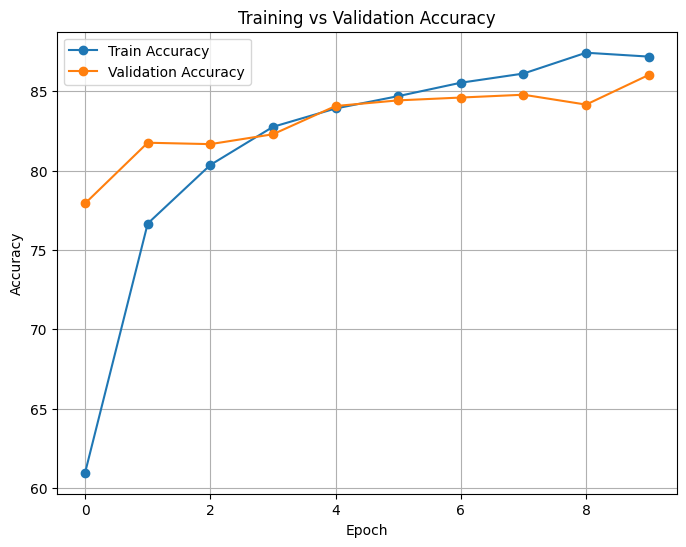

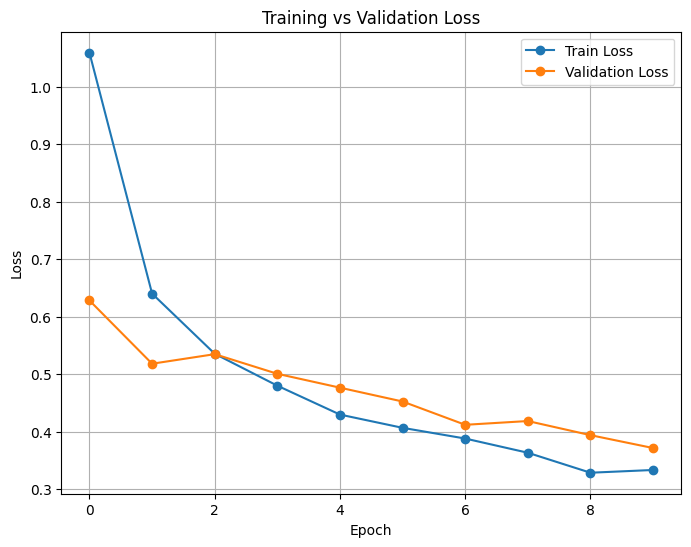


Classification Report


Model Saved Successfully


In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

import timm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)



device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using Device:", device)



IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 10
LEARNING_RATE = 1e-4


dataset_paths = {

    "skin_cancer":
    "/kaggle/input/datasets/nodoubttome/skin-cancer9-classesisic/",

    "brain_tumor":
    "/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Training",

    "diabetic_retinopathy":
    "/kaggle/input/datasets/sachinkumar413/diabetic-retinopathy-dataset"

}

image_paths = []
labels = []

class_names = []
label_counter = 0

print("\nLoading Dataset...\n")

for dataset_name, dataset_path in dataset_paths.items():

    print(f"Processing: {dataset_name}")

    for subclass in os.listdir(dataset_path):

        subclass_path = os.path.join(
            dataset_path,
            subclass
        )

        if os.path.isdir(subclass_path):

            print("Subclass:", subclass)

            class_names.append(subclass)

            for file in os.listdir(subclass_path):

                if file.lower().endswith(
                    ('.jpg', '.png', '.jpeg')
                ):

                    image_paths.append(
                        os.path.join(subclass_path, file)
                    )

                    labels.append(label_counter)

            label_counter += 1



NUM_CLASSES = len(class_names)

print("\nTotal Classes:", NUM_CLASSES)

print("Class Names:\n")

for idx, name in enumerate(class_names):

    print(idx, ":", name)



train_paths, test_paths, train_labels, test_labels = train_test_split(

    image_paths,
    labels,

    test_size=0.2,

    stratify=labels,

    random_state=42

)



train_transform = transforms.Compose([

    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(20),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )

])

test_transform = transforms.Compose([

    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )

])



class MedicalDataset(Dataset):

    def __init__(
        self,
        image_paths,
        labels,
        transform=None
    ):

        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):

        return len(self.image_paths)

    def __getitem__(self, idx):

        image = Image.open(
            self.image_paths[idx]
        ).convert("RGB")

        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label



train_dataset = MedicalDataset(
    train_paths,
    train_labels,
    train_transform
)

test_dataset = MedicalDataset(
    test_paths,
    test_labels,
    test_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)



class AttentionFusion(nn.Module):

    def __init__(self, dim):

        super(AttentionFusion, self).__init__()

        self.alpha = nn.Parameter(
            torch.rand(1)
        )

    def forward(self, cnn_feat, vit_feat):

        alpha = torch.sigmoid(self.alpha)

        fused = (
            alpha * cnn_feat
            +
            (1 - alpha) * vit_feat
        )

        return fused


class HybridModel(nn.Module):

    def __init__(self, num_classes):

        super(HybridModel, self).__init__()



        self.cnn = timm.create_model(

            'efficientnet_b0',

            pretrained=True,

            num_classes=0

        )



        self.vit = timm.create_model(

            'vit_base_patch16_224',

            pretrained=True,

            num_classes=0

        )



        self.cnn_proj = nn.Sequential(

            nn.Linear(1280, 512),

            nn.ReLU(),

            nn.Dropout(0.3)

        )

        self.vit_proj = nn.Sequential(

            nn.Linear(768, 512),

            nn.ReLU(),

            nn.Dropout(0.3)

        )



        self.fusion = AttentionFusion(512)



        self.classifier = nn.Sequential(

            nn.Linear(512, 256),

            nn.ReLU(),

            nn.Dropout(0.4),

            nn.Linear(256, num_classes)

        )

    def forward(self, x):

        cnn_feat = self.cnn(x)

        vit_feat = self.vit(x)

        cnn_feat = self.cnn_proj(cnn_feat)

        vit_feat = self.vit_proj(vit_feat)

        fused = self.fusion(
            cnn_feat,
            vit_feat
        )

        output = self.classifier(fused)

        return output



model = HybridModel(NUM_CLASSES).to(device)


criterion = nn.CrossEntropyLoss()



optimizer = optim.AdamW(

    model.parameters(),

    lr=LEARNING_RATE

)


scheduler = optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode='min',

    patience=2,

    factor=0.5

)



train_acc_history = []
val_acc_history = []

train_loss_history = []
val_loss_history = []

print("\nStarting Training...\n")

for epoch in range(EPOCHS):

    model.train()

    train_correct = 0
    train_total = 0
    train_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        _, preds = torch.max(outputs, 1)

        train_total += labels.size(0)

        train_correct += (
            preds == labels
        ).sum().item()

    train_accuracy = (
        100 * train_correct / train_total
    )

    train_loss = (
        train_loss / len(train_loader)
    )


    model.eval()

    val_correct = 0
    val_total = 0
    val_loss = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            val_total += labels.size(0)

            val_correct += (
                preds == labels
            ).sum().item()

    val_accuracy = (
        100 * val_correct / val_total
    )

    val_loss = val_loss / len(test_loader)

    scheduler.step(val_loss)

    train_acc_history.append(train_accuracy)
    val_acc_history.append(val_accuracy)

    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")

    print(f"Train Loss: {train_loss:.4f}")

    print(f"Train Accuracy: {train_accuracy:.2f}%")

    print(f"Validation Loss: {val_loss:.4f}")

    print(f"Validation Accuracy: {val_accuracy:.2f}%")



plt.figure(figsize=(8,6))

plt.plot(
    train_acc_history,
    marker='o',
    label='Train Accuracy'
)

plt.plot(
    val_acc_history,
    marker='o',
    label='Validation Accuracy'
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.grid()

plt.show()


plt.figure(figsize=(8,6))

plt.plot(
    train_loss_history,
    marker='o',
    label='Train Loss'
)

plt.plot(
    val_loss_history,
    marker='o',
    label='Validation Loss'
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.grid()

plt.show()



model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )



print("\nClassification Report\n")

# print(

#     classification_report(

#         all_labels,

#         all_preds,

#         target_names=class_names

#     )

# )



# cm = confusion_matrix(
#     all_labels,
#     all_preds
# )

# plt.figure(figsize=(12,10))

# sns.heatmap(

#     cm,

#     annot=True,

#     fmt='d',

#     cmap='Blues',

#     xticklabels=class_names,

#     yticklabels=class_names

# )

# plt.xlabel("Predicted")

# plt.ylabel("Actual")

# plt.title("Confusion Matrix")

# plt.show()



# model.eval()

# fig = plt.figure(figsize=(15,12))

# for i in range(9):

#     idx = random.randint(
#         0,
#         len(test_dataset)-1
#     )

#     image, label = test_dataset[idx]

#     input_img = image.unsqueeze(0).to(device)

#     with torch.no_grad():

#         output = model(input_img)

#         _, pred = torch.max(output, 1)

#     # De-normalize
#     image_np = image.permute(1,2,0).numpy()

#     image_np = (
#         image_np * np.array([0.229,0.224,0.225])
#         +
#         np.array([0.485,0.456,0.406])
#     )

#     image_np = np.clip(image_np, 0, 1)

#     ax = fig.add_subplot(3,3,i+1)

#     ax.imshow(image_np)

#     ax.set_title(

#         f"True: {class_names[label]}\n"

#         f"Pred: {class_names[pred.item()]}"

#     )

#     ax.axis("off")

# plt.tight_layout()

# plt.show()



torch.save(

    model.state_dict(),

    "Hybrid_Biomedical_Model.pth"

)

print("\nModel Saved Successfully")

In [14]:

print("\nClassification Report\n")

unique_labels = sorted(
    list(set(all_labels))
)

valid_class_names = [

    class_names[i]

    for i in unique_labels

]

print(

    classification_report(

        all_labels,

        all_preds,

        labels=unique_labels,

        target_names=valid_class_names,

        zero_division=0

    )

)


Classification Report

                  precision    recall  f1-score   support

        no_tumor       0.99      0.99      0.99        79
 pituitary_tumor       0.99      1.00      1.00       166
meningioma_tumor       0.99      0.98      0.98       164
    glioma_tumor       0.99      0.99      0.99       165
       Severe DR       0.34      0.32      0.33        38
         Healthy       0.97      0.98      0.98       200
     Moderate DR       0.69      0.74      0.72       180
         Mild DR       0.67      0.49      0.56        74
  Proliferate DR       0.44      0.48      0.46        58

        accuracy                           0.87      1124
       macro avg       0.78      0.77      0.78      1124
    weighted avg       0.87      0.87      0.87      1124



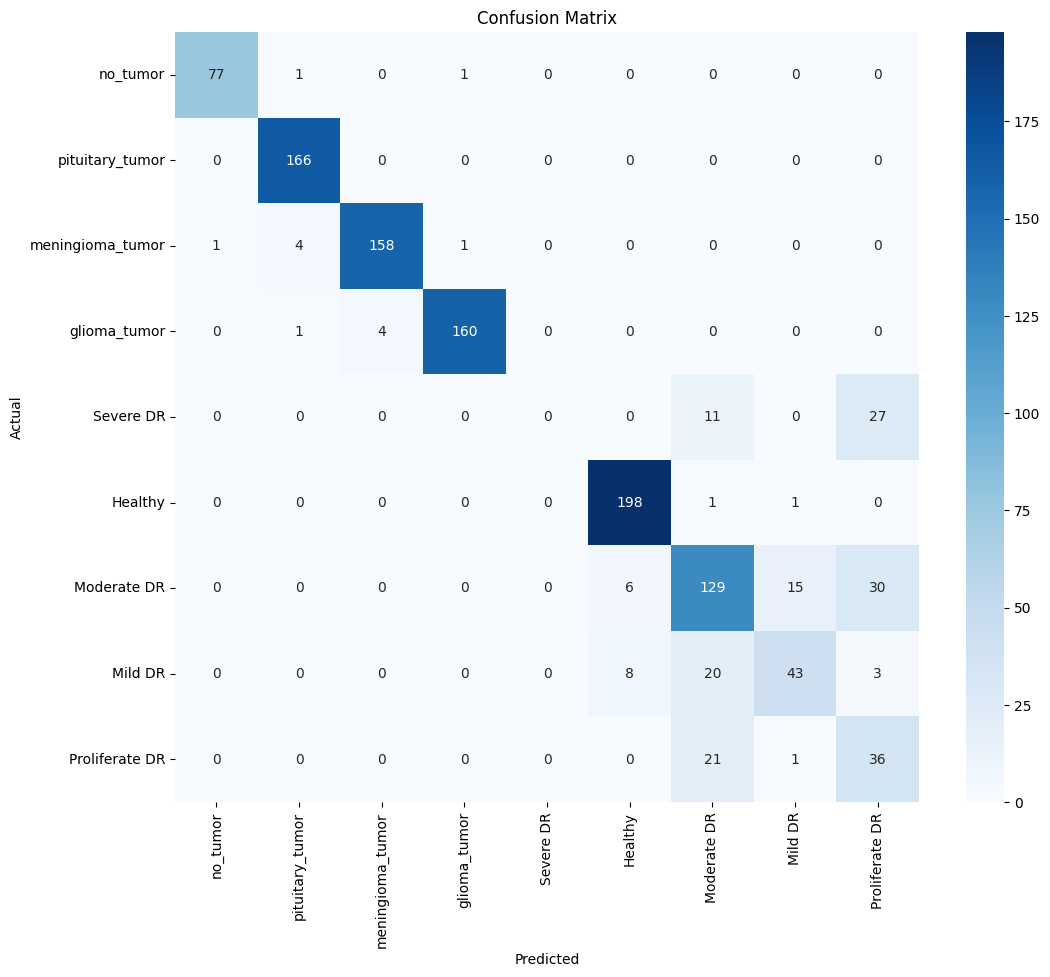

In [3]:

cm = confusion_matrix(

    all_labels,

    all_preds,

    labels=unique_labels

)

plt.figure(figsize=(12,10))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=valid_class_names,

    yticklabels=valid_class_names

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

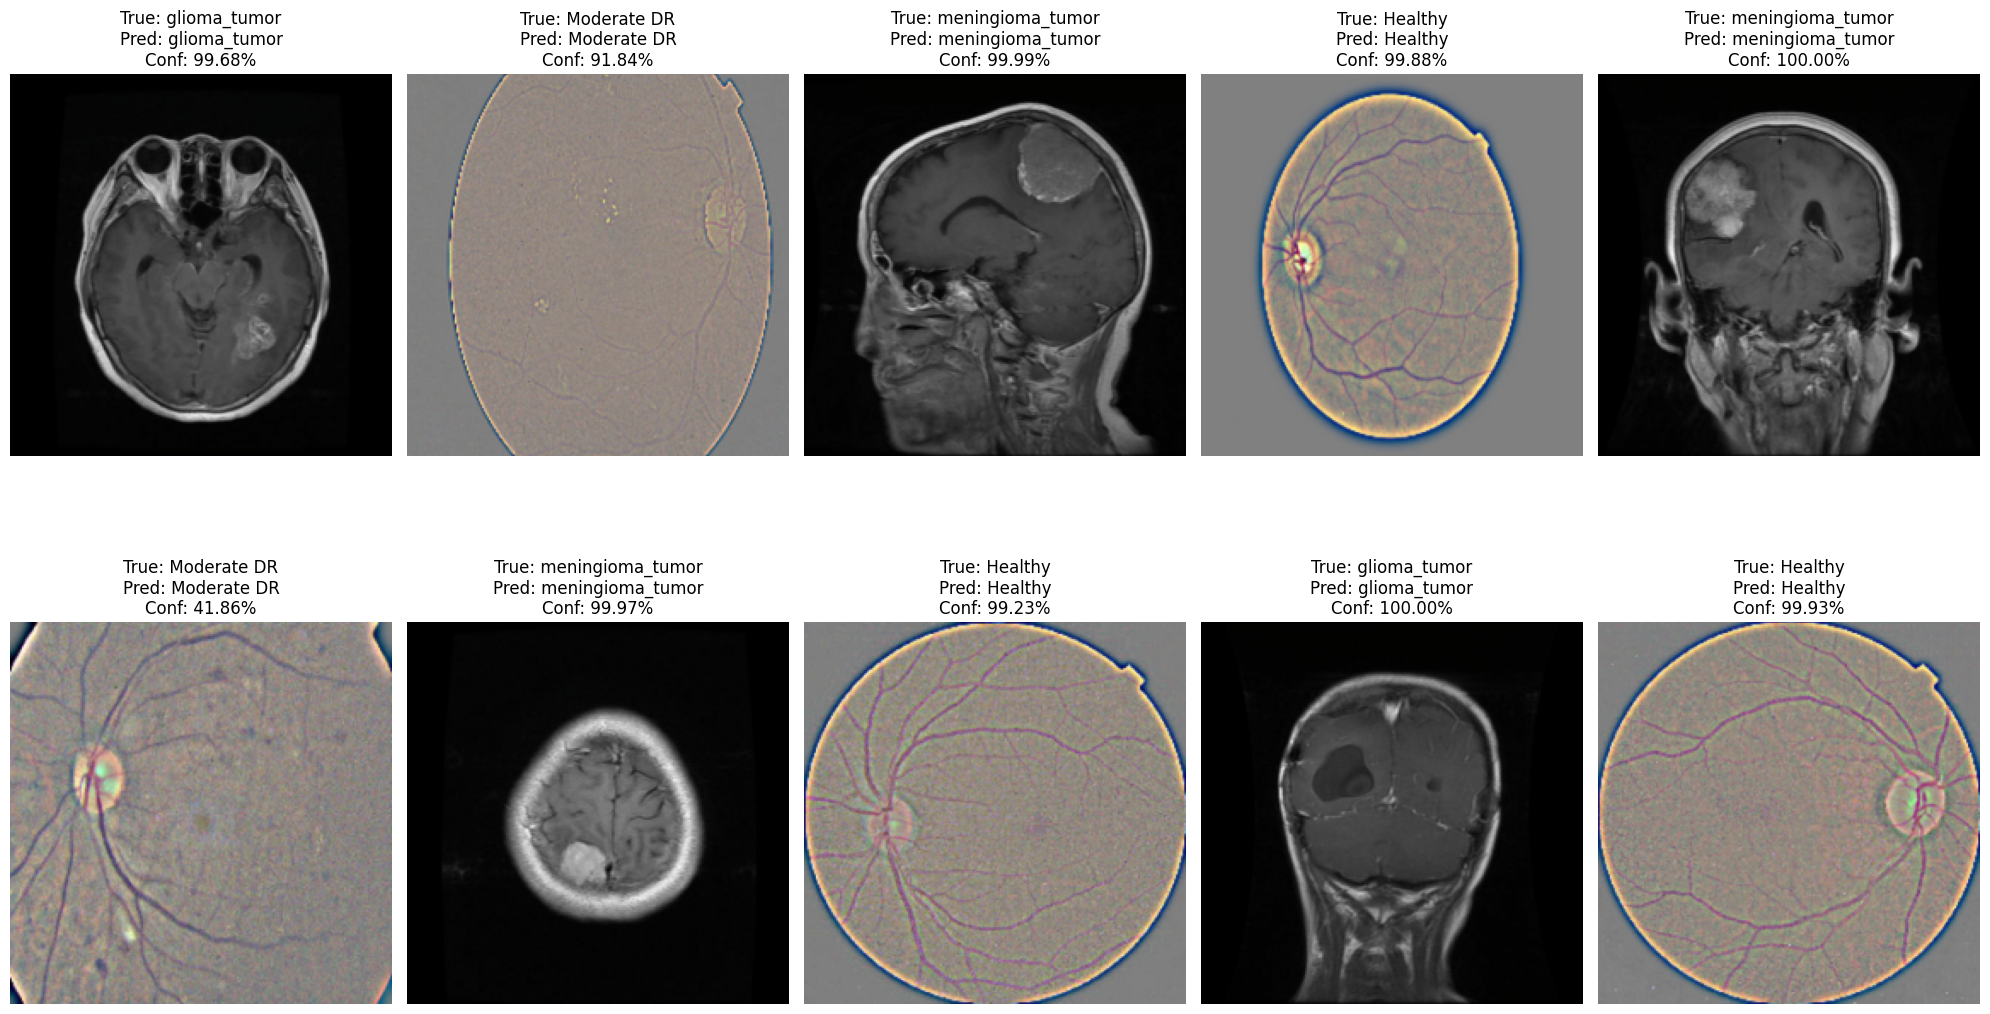

In [5]:

model.eval()

num_images = 10

fig = plt.figure(figsize=(20, 12))

with torch.no_grad():

    for i in range(num_images):



        idx = random.randint(
            0,
            len(test_dataset) - 1
        )

        image, label = test_dataset[idx]

       

        input_tensor = image.unsqueeze(0).to(device)

        # ====================================================
        # PREDICTION
        # ====================================================

        output = model(input_tensor)

        probabilities = torch.softmax(
            output,
            dim=1
        )

        confidence, pred = torch.max(
            probabilities,
            1
        )

        pred_class = class_names[pred.item()]

        true_class = class_names[label]

        confidence = confidence.item() * 100



        image_np = image.permute(1, 2, 0).cpu().numpy()

        image_np = (

            image_np * np.array(
                [0.229, 0.224, 0.225]
            )

            +

            np.array(
                [0.485, 0.456, 0.406]
            )

        )

        image_np = np.clip(
            image_np,
            0,
            1
        )


        ax = fig.add_subplot(2, 5, i + 1)

        ax.imshow(image_np)

        ax.set_title(

            f"True: {true_class}\n"

            f"Pred: {pred_class}\n"

            f"Conf: {confidence:.2f}%"

        )

        ax.axis("off")

plt.tight_layout()

plt.show()